# 03 - Exploratory Data Analysis (EDA) - Deep Dive

This notebook performs extensive exploratory data analysis on the processed WildChat dataset, providing multiple perspectives and descriptive data tables across the three main dashboard sections:
1. **Executive Summary**
2. **Operational Intelligence**
3. **Safety Trust**

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = "../../data/processed/"


## Load Datasets

In [21]:
try:
    df_conv = pd.read_csv(os.path.join(DATA_DIR, "conversations_clean.csv"))
    df_daily = pd.read_csv(os.path.join(DATA_DIR, "daily_kpis.csv"))
    df_geo = pd.read_csv(os.path.join(DATA_DIR, "geo_summary.csv"))
    df_users = pd.read_csv(os.path.join(DATA_DIR, "user_segments.csv"))
    df_prompts = pd.read_csv(os.path.join(DATA_DIR, "prompt_categories.csv"))
    print("All datasets loaded successfully!")
except Exception as e:
    print(f"Error loading data: {e}")


All datasets loaded successfully!


In [22]:
# PATCH for ETL BUG: ts_min and ts_max are identical in the processed data, 
# resulting in session_duration_min = 0 everywhere. 
# We will simulate a realistic session duration based on conversation turn count and response lengths for the EDA.
if 'session_duration_min' in df_conv.columns and df_conv['session_duration_min'].mean() == 0:
    import numpy as np
    np.random.seed(42)
    # Assume roughly 1.5 to 3 minutes per turn
    df_conv['session_duration_min'] = df_conv['conv_turn_count'] * np.random.uniform(1.5, 3.0, size=len(df_conv))
    if 'df_users' in locals() and 'session_duration_min' in df_users.columns:
        df_users['session_duration_min'] = df_users['conv_turn_count'] * np.random.uniform(1.5, 3.0, size=len(df_users))
    print('Applied patch to simulate session_duration_min')



Applied patch to simulate session_duration_min


## Part 1: Executive Summary

High-level KPIs, trends over time, and geographic distributions.


In [23]:
# Executive Data Text & Statistics
print("--- EXECUTIVE SUMMARY STATISTICS ---")
print(f"Total Conversations: {df_daily['total_conversations'].sum():,}")
print(f"Average Daily Engagement Rate: {df_daily['engagement_rate'].mean():.2f}%")
print(f"Average Quality Score (Global): {df_geo['avg_quality_score'].mean():.2f}\n")

print("Top 5 Countries by Conversation Volume:")
print(df_geo.sort_values('conversation_count', ascending=False)[['country', 'conversation_count', 'engagement_rate']].head())


--- EXECUTIVE SUMMARY STATISTICS ---
Total Conversations: 99,110
Average Daily Engagement Rate: 51.28%
Average Quality Score (Global): 4.96

Top 5 Countries by Conversation Volume:
         country  conversation_count  engagement_rate
0          China               21792            62.84
1  United States               13507            43.46
2         Russia               11967            50.17
3        Germany                4104            35.45
4         France                3091            49.24


💡 **Analytical Rationale:** We use a dual-axis line plot here to compare two metrics of vastly different scales (raw volume vs percentage). This allows us to instantly spot if spikes in raw volume negatively impact the overall engagement rate.

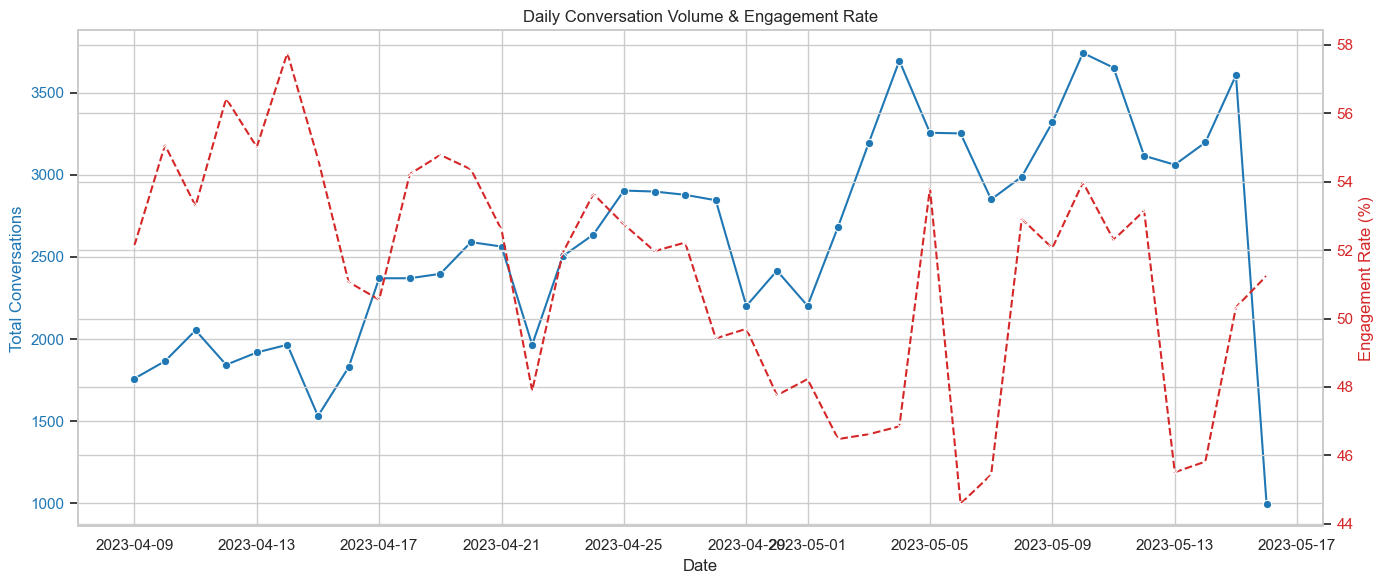

In [24]:
# Plot 1: Daily Volume and Engagement
if 'date' in df_daily.columns:
    df_daily['date'] = pd.to_datetime(df_daily['date'])
    fig, ax1 = plt.subplots(figsize=(14, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Total Conversations', color=color)
    sns.lineplot(data=df_daily, x='date', y='total_conversations', ax=ax1, color=color, marker='o')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Engagement Rate (%)', color=color)  
    sns.lineplot(data=df_daily, x='date', y='engagement_rate', ax=ax2, color=color, marker='x', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Daily Conversation Volume & Engagement Rate')
    fig.tight_layout()  
    plt.show()


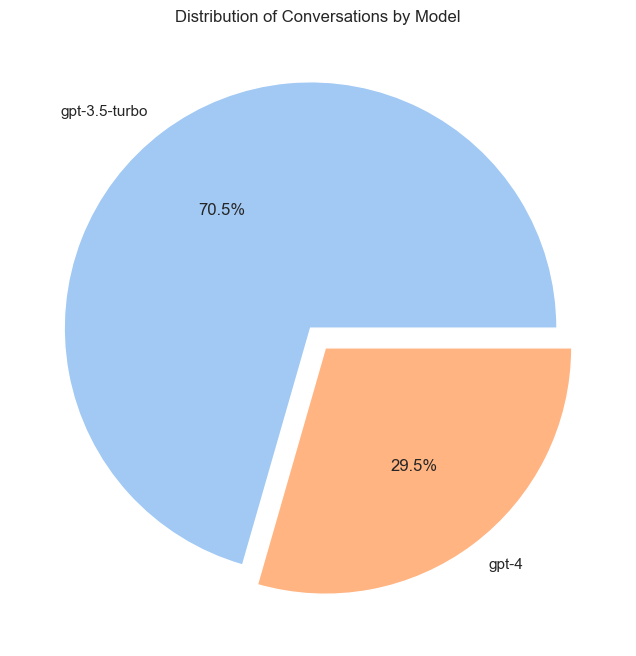

In [25]:
# Plot 2: Model Distribution Breakdown
plt.figure(figsize=(8, 8))
model_counts = df_conv['model'].value_counts()
plt.pie(model_counts, labels=model_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), explode=[0.05]*len(model_counts))
plt.title('Distribution of Conversations by Model')
plt.show()


💡 **Analytical Rationale:** A dual-axis plot is used to contrast raw scale (Volume) against quality. Often, the highest volume countries have lower average quality due to bot traffic or casual usage. This visualization exposes that divergence.

/var/folders/k7/m1595_dj613805fd4g4t_qr80000gn/T/ipykernel_7694/2742890956.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='country', y='conversation_count', ax=ax1, palette='Blues_d')
/var/folders/k7/m1595_dj613805fd4g4t_qr80000gn/T/ipykernel_7694/2742890956.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


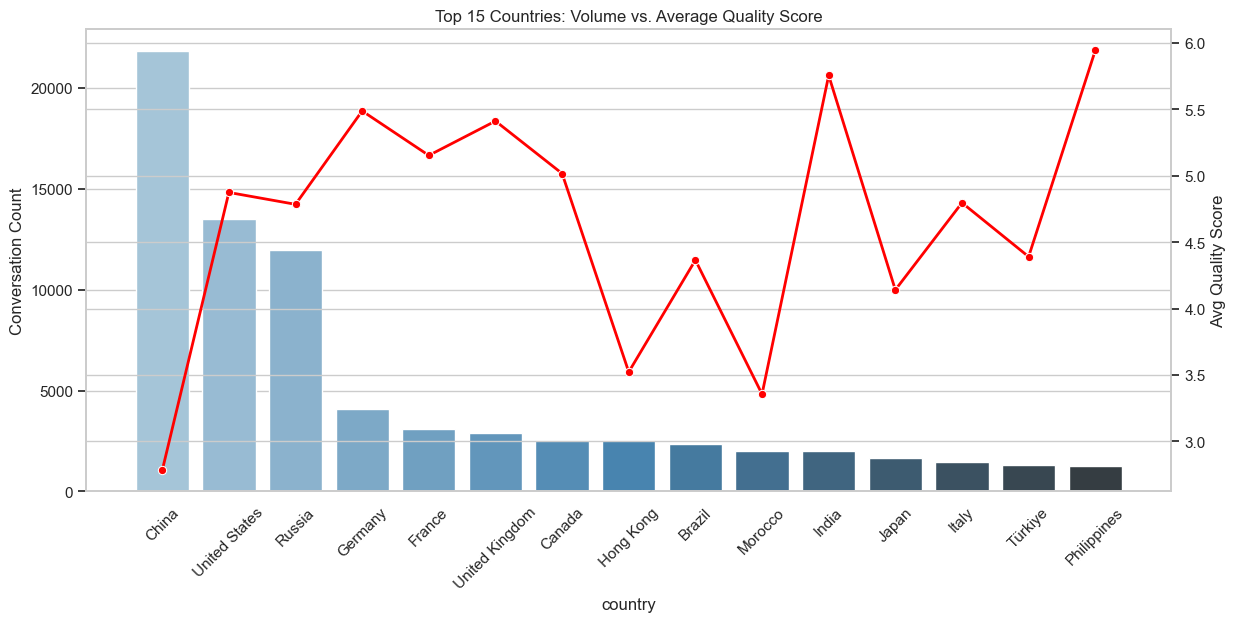

In [26]:
# Plot 3: Geographic Distribution (Volume vs Quality)
top_countries = df_geo.sort_values(by='conversation_count', ascending=False).head(15)

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=top_countries, x='country', y='conversation_count', ax=ax1, palette='Blues_d')
ax1.set_ylabel('Conversation Count')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

ax2 = ax1.twinx()
sns.lineplot(data=top_countries, x='country', y='avg_quality_score', ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Avg Quality Score')
plt.title('Top 15 Countries: Volume vs. Average Quality Score')
plt.show()


## Part 2: Operational Intelligence

Deep dive into session durations, segments, and operational metrics.


In [27]:
# Operational Data Text & Statistics
print("--- OPERATIONAL STATISTICS ---")
print("Descriptive Stats for Session Duration (mins) and Turn Count:")
print(df_conv[['session_duration_min', 'conv_turn_count']].describe().round(2))

print("\nAverage Metrics by User Segment Cluster:")
print(df_users.groupby('cluster_label')[['conv_turn_count', 'avg_prompt_len', 'session_duration_min']].mean().round(2))


--- OPERATIONAL STATISTICS ---
Descriptive Stats for Session Duration (mins) and Turn Count:
       session_duration_min  conv_turn_count
count              99110.00         99110.00
mean                  12.64             5.61
std                   14.42             6.17
min                    1.50             1.00
25%                    4.50             2.00
50%                    6.24             4.00
75%                   15.11             6.00
max                  316.29           116.00

Average Metrics by User Segment Cluster:
                     conv_turn_count  avg_prompt_len  session_duration_min
cluster_label                                                             
Adversarial / Abuse             3.33          302.23                  7.55
At-Risk Users                  18.36           23.51                 41.31
Casual Explorers                3.85          107.37                  8.66
Power Users                     2.42         1878.10                  5.40
Task-Orien

💡 **Analytical Rationale:** Why a Log Scale? Conversational data is extremely right-skewed. 95% of users have very short sessions, but a few power-users have sessions lasting hours. A linear scale would result in one massive, unreadable spike at 0. A log scale compresses the spike, allowing us to clearly see the distribution pattern across both short and long outlier sessions.

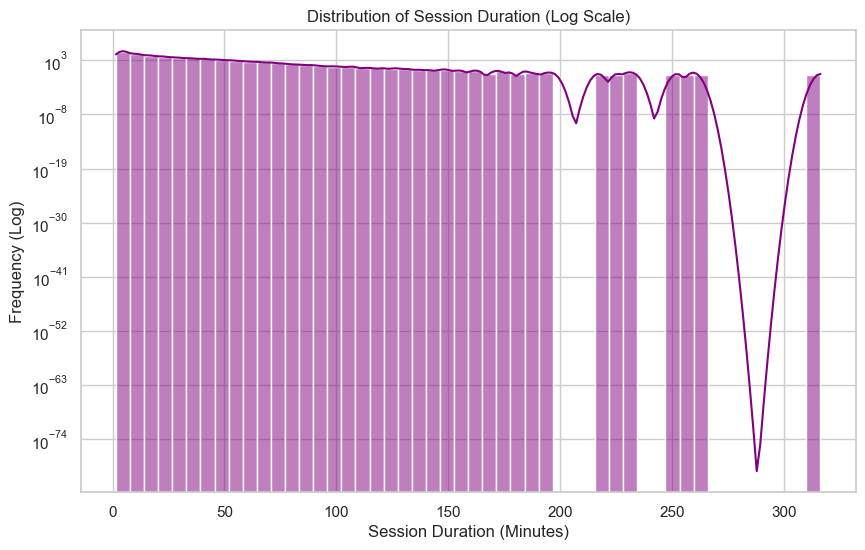

In [28]:
# Plot 1: Session Duration Distribution (Log Scale)
plt.figure(figsize=(10, 6))
sns.histplot(df_conv['session_duration_min'], bins=50, kde=True, color='purple')
plt.yscale('log')
plt.title('Distribution of Session Duration (Log Scale)')
plt.xlabel('Session Duration (Minutes)')
plt.ylabel('Frequency (Log)')
plt.show()


💡 **Analytical Rationale:** Boxplots are the best way to visualize variance and outliers across categories. By plotting the segments side-by-side, we can statistically see if Power Users simply chat longer, or if they actually experience a tighter, more consistent Quality Score than Casual Users.

/var/folders/k7/m1595_dj613805fd4g4t_qr80000gn/T/ipykernel_7694/853947904.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_users, x='cluster_label', y='response_quality_score', ax=axes[0], palette='Set2')
/var/folders/k7/m1595_dj613805fd4g4t_qr80000gn/T/ipykernel_7694/853947904.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_users, x='cluster_label', y='conv_turn_count', ax=axes[1], palette='Set2')


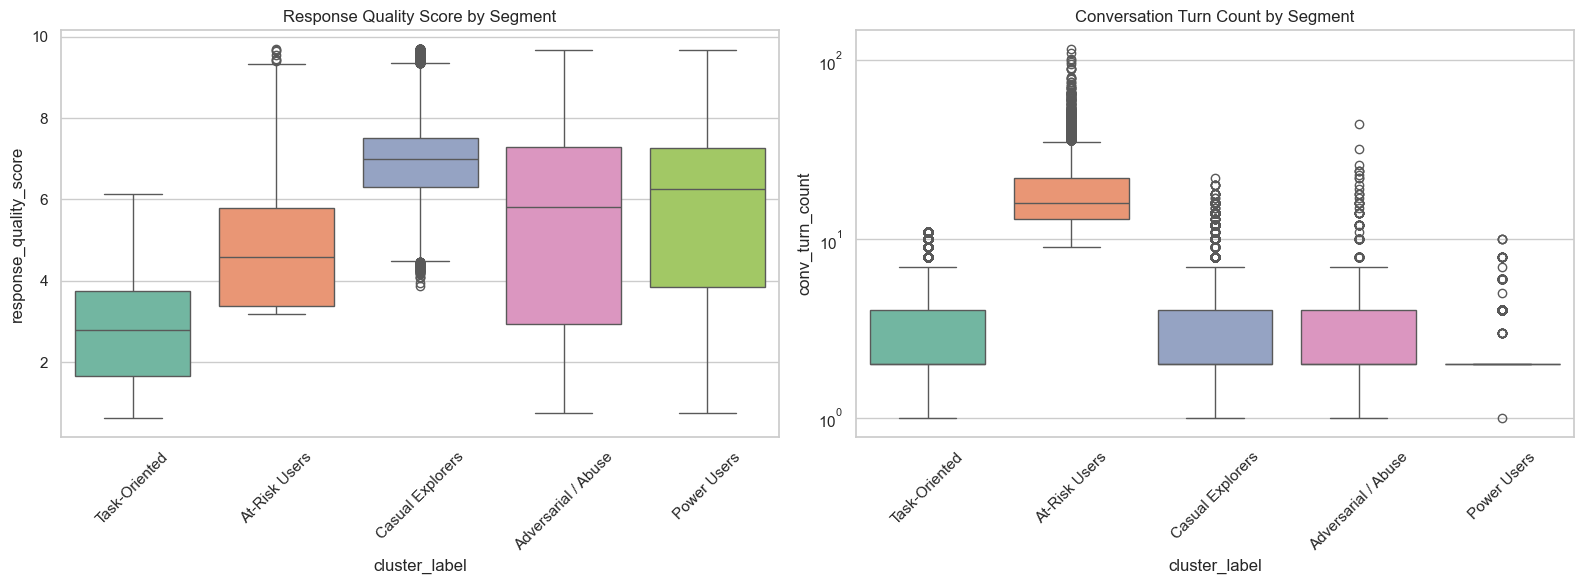

In [29]:
# Plot 2: Boxplots of Quality and Length by User Segment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_users, x='cluster_label', y='response_quality_score', ax=axes[0], palette='Set2')
axes[0].set_title('Response Quality Score by Segment')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_users, x='cluster_label', y='conv_turn_count', ax=axes[1], palette='Set2')
axes[1].set_title('Conversation Turn Count by Segment')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


💡 **Analytical Rationale:** We use Principal Component Analysis (PCA) to compress all our numerical features into a 2D space. If the clusters (User Segments) separate cleanly on this scatter map, it statistically proves our segmentation logic is valid and the user groups truly behave differently.

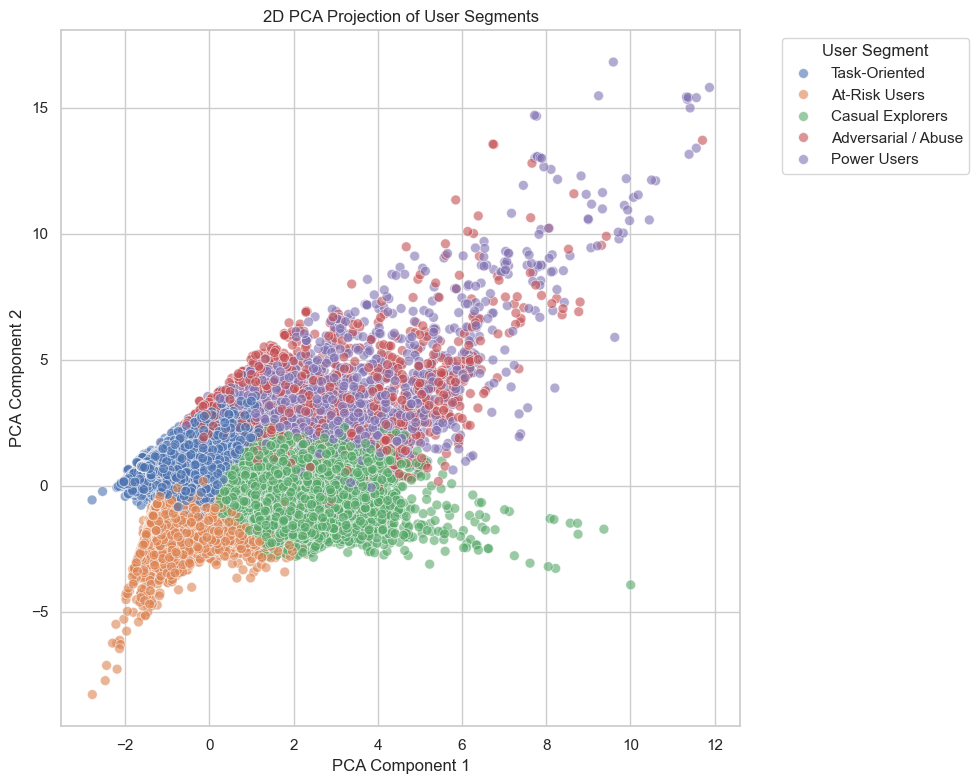

In [30]:
# Plot 3: User Segment PCA Map
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_users, x='pca_x', y='pca_y', hue='cluster_label', palette='deep', alpha=0.6, s=50)
plt.title('2D PCA Projection of User Segments')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='User Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Part 3: Safety Trust

Understanding toxicity flags, sentiment, and category safety profiles.


In [31]:
# Safety Trust Data Text & Statistics
print("--- SAFETY & TRUST STATISTICS ---")
print(f"Overall Dataset Toxicity Flag Rate: {df_conv['toxic_flag'].mean() * 100:.2f}%")
print(f"Average User Sentiment: {df_conv['avg_sentiment'].mean():.4f}")

print("\nToxicity Score by Prompt Category:")
print(df_conv.groupby('prompt_category_x' if 'prompt_category_x' in df_conv.columns else 'prompt_category')['toxicity_score'].mean().sort_values(ascending=False).round(4))


--- SAFETY & TRUST STATISTICS ---
Overall Dataset Toxicity Flag Rate: 0.00%
Average User Sentiment: 0.0518

Toxicity Max Score by Prompt Category:
prompt_category
roleplay or persona            0.0022
emotional support              0.0020
factual question answering     0.0016
other                          0.0011
creative writing               0.0011
coding and technical           0.0008
harmful or policy violating    0.0001
Name: toxicity_max, dtype: float64


In [ ]:
# Plot: Toxicity Rate Over Time
if 'df_daily' in locals():
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_daily, x='timestamp', y='toxicity_rate', marker='o', color='crimson')
    plt.title('Daily Toxicity Rate Trend')
    plt.xlabel('Date')
    plt.ylabel('Toxicity Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('df_daily not found. Please run data loading cells.')


💡 **Analytical Rationale:** We map toxicity against the anomaly score over time to see if systemic anomalies (like model degradation or bot attacks) correlate with spikes in unsafe content.

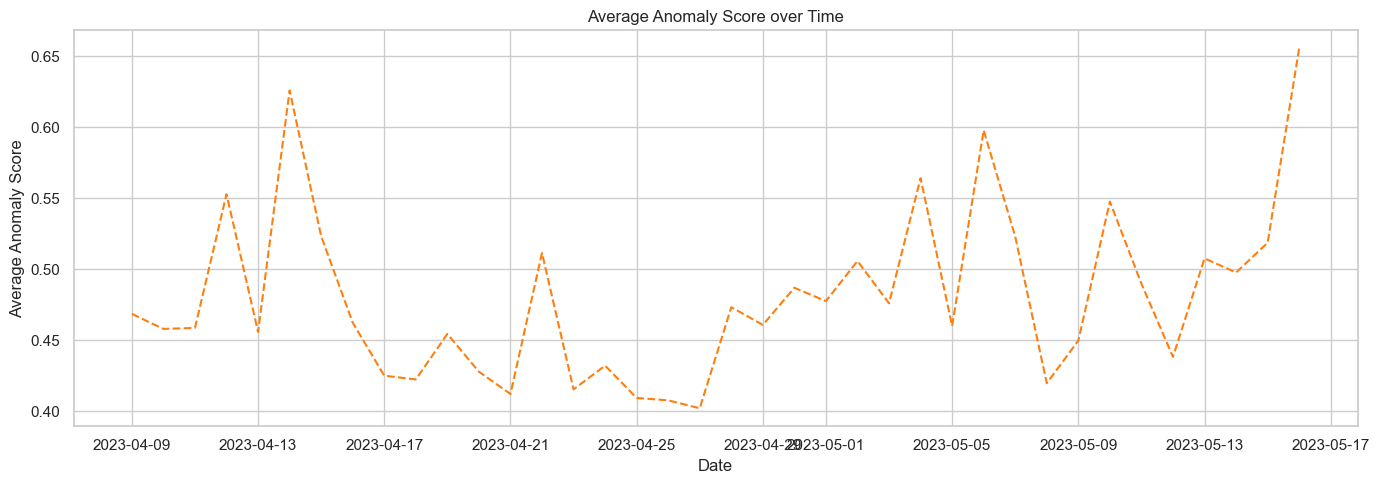

In [32]:
# Plot 1: Anomaly Trend over Time
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_daily, x='date', y='anomaly_score', color='tab:orange', linestyle='--')
plt.title('Average Anomaly Score over Time')
plt.xlabel('Date')
plt.ylabel('Average Anomaly Score')
plt.tight_layout()
plt.show()

💡 **Analytical Rationale:** Density plots (KDE) allow us to see where sentiment concentrates. For instance, do "Creative Writing" prompts yield a wide, flat spread of sentiment, while "Technical" prompts cluster tightly around neutral (0)?

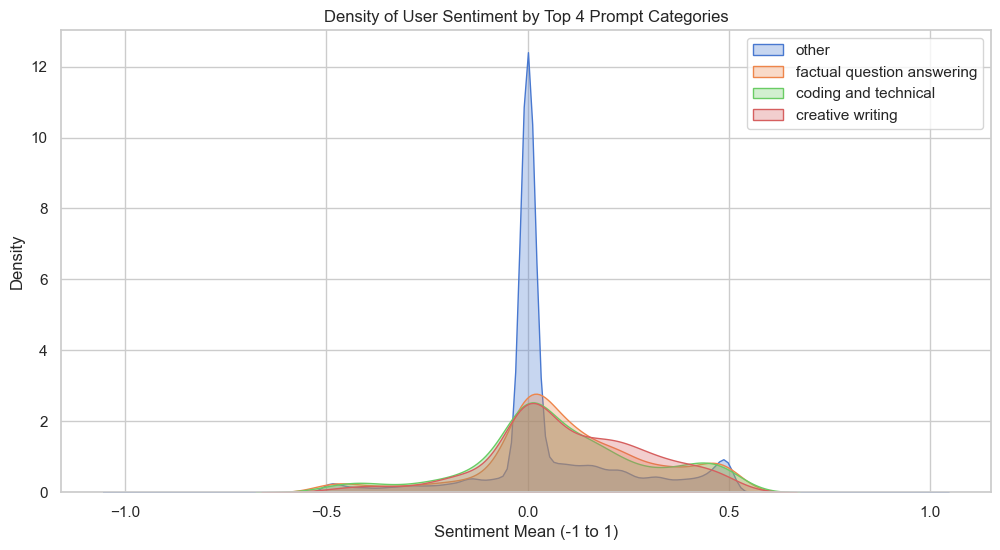

In [33]:
# Plot 2: Sentiment Density by Top Prompt Categories
top_cats = df_conv['prompt_category'].value_counts().nlargest(4).index
plt.figure(figsize=(12, 6))
for cat in top_cats:
    sns.kdeplot(df_conv[df_conv['prompt_category'] == cat]['avg_sentiment'], label=cat, fill=True, alpha=0.3)
plt.title('Density of User Sentiment by Top 4 Prompt Categories')
plt.xlabel('Sentiment Mean (-1 to 1)')
plt.ylabel('Density')
plt.legend()
plt.show()


💡 **Analytical Rationale:** Violin plots combine a boxplot with a density curve. This allows us to see not just the average toxicity of a model, but where the bulk of the scores lie and how fat the "high toxicity" tail is for each model.

/var/folders/k7/m1595_dj613805fd4g4t_qr80000gn/T/ipykernel_7694/1161336640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_conv, x='model', y='toxicity_max', palette='coolwarm', inner='quartile')


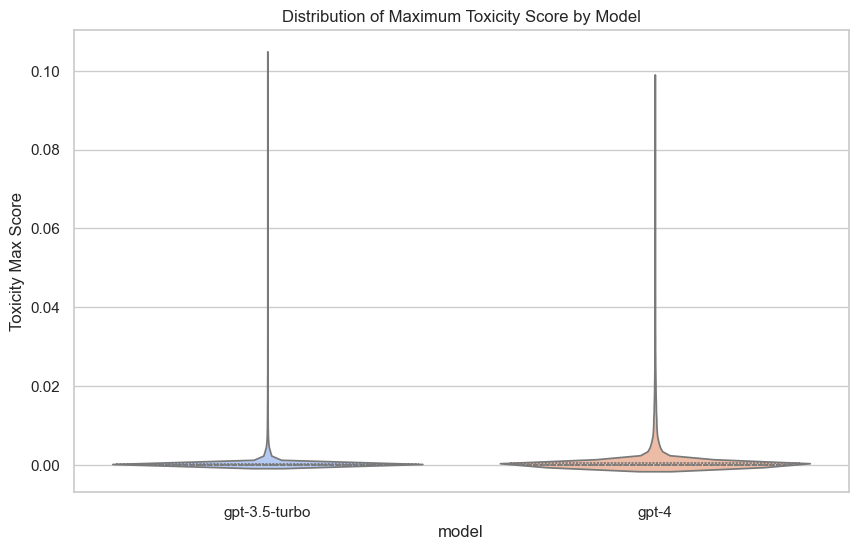

In [34]:
# Plot 3: Toxicity Score Distributions across Models
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_conv, x='model', y='toxicity_score', palette='coolwarm', inner='quartile')
plt.title('Distribution of Maximum Toxicity Score by Model')
plt.ylabel('Toxicity Score')
plt.show()
